# 第 1 次课：人工智能概述

这节课只解决一个核心问题：**AI 到底是什么，它为什么会在今天变成大模型、VLM、RAG 和 Agent？**

本节课的讲法：先建立全局地图，再用几个可视化小实验把“模型、数据、学习、生成、智能体”这些词落到具体画面上。

In [1]:
from IPython.display import HTML, display
import math
import random
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

THEME = {
    "ink": "#172026",
    "muted": "#66717a",
    "line": "#d9e1e7",
    "bg": "#f7f9fb",
    "blue": "#2563eb",
    "green": "#16a34a",
    "orange": "#f97316",
    "red": "#dc2626",
    "purple": "#7c3aed",
    "cyan": "#0891b2",
}

def show(html):
    display(HTML(html))

show("""
<style>
.ai-course {font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", "PingFang SC", "Microsoft YaHei", sans-serif; color:#172026;}
.ai-course * {box-sizing:border-box; letter-spacing:0;}
.ai-hero {padding:28px 30px; border:1px solid #d9e1e7; border-radius:8px; background:linear-gradient(135deg,#f7f9fb,#ffffff); position:relative; overflow:hidden;}
.ai-hero h2 {margin:0 0 10px; font-size:32px; line-height:1.2;}
.ai-hero p {margin:6px 0; font-size:17px; color:#4b5563;}
.ai-grid {display:grid; grid-template-columns:repeat(3,minmax(0,1fr)); gap:14px; margin:18px 0;}
.ai-grid.two {grid-template-columns:repeat(2,minmax(0,1fr));}
.ai-card {border:1px solid #d9e1e7; border-radius:8px; padding:16px 18px; background:#fff; min-height:112px;}
.ai-card h3 {margin:0 0 8px; font-size:20px;}
.ai-card p, .ai-card li {font-size:15px; color:#4b5563; line-height:1.65;}
.ai-tag {display:inline-flex; align-items:center; padding:4px 9px; border-radius:999px; background:#eef2ff; color:#1d4ed8; font-size:13px; font-weight:650; margin:3px 6px 3px 0;}
.ai-row {display:flex; align-items:center; gap:10px; flex-wrap:wrap;}
.ai-arrow {font-size:24px; color:#64748b;}
.ai-box {border:1px solid #d9e1e7; border-radius:8px; padding:14px; background:#fff; text-align:center; min-width:130px;}
.ai-box strong {display:block; font-size:18px; margin-bottom:4px;}
.ai-box span {font-size:13px; color:#66717a;}
.ai-note {border-left:4px solid #2563eb; padding:10px 14px; background:#eff6ff; margin:14px 0; color:#1e3a8a;}
.ai-warn {border-left:4px solid #f97316; padding:10px 14px; background:#fff7ed; margin:14px 0; color:#9a3412;}
.ai-stage {height:300px; border:1px solid #d9e1e7; border-radius:8px; background:#ffffff; position:relative; overflow:hidden; margin:16px 0;}
.node {position:absolute; width:138px; min-height:70px; border:2px solid #d9e1e7; border-radius:8px; background:#fff; display:flex; flex-direction:column; align-items:center; justify-content:center; box-shadow:0 8px 20px rgba(15,23,42,.08);}
.node b {font-size:18px;}
.node small {color:#66717a; margin-top:4px;}
.packet {position:absolute; width:18px; height:18px; border-radius:50%; background:#2563eb; top:138px; left:104px; animation: flow 4.8s ease-in-out infinite; box-shadow:0 0 0 8px rgba(37,99,235,.12);}
.packet.two {animation-delay:1.2s; background:#16a34a; box-shadow:0 0 0 8px rgba(22,163,74,.12);}
.packet.three {animation-delay:2.4s; background:#f97316; box-shadow:0 0 0 8px rgba(249,115,22,.14);}
@keyframes flow {0%{transform:translateX(0); opacity:0} 10%{opacity:1} 42%{transform:translateX(260px)} 72%{transform:translateX(520px)} 100%{transform:translateX(710px); opacity:0}}
.pulse {animation:pulse 2.2s infinite;}
@keyframes pulse {0%,100%{box-shadow:0 0 0 0 rgba(37,99,235,.25)} 50%{box-shadow:0 0 0 14px rgba(37,99,235,0)}}
.ladder {display:grid; grid-template-columns:160px 1fr; gap:10px; align-items:center; margin:16px 0;}
.ladder .label {font-weight:700;}
.bar {height:34px; border-radius:6px; background:#e5e7eb; overflow:hidden;}
.bar span {height:100%; display:block; color:#fff; padding-left:12px; line-height:34px; font-size:14px; white-space:nowrap;}
.timeline {display:grid; grid-template-columns:repeat(6,1fr); gap:10px; margin:16px 0;}
.titem {border-top:4px solid #2563eb; background:#fff; border-radius:6px; padding:12px; border-left:1px solid #d9e1e7; border-right:1px solid #d9e1e7; border-bottom:1px solid #d9e1e7; min-height:126px;}
.titem b {font-size:17px;}
.titem p {font-size:13px; color:#66717a; line-height:1.55;}
.orbit {height:320px; position:relative; border:1px solid #d9e1e7; border-radius:8px; background:#fff; overflow:hidden;}
.circle {position:absolute; border:2px solid; border-radius:50%; display:flex; align-items:center; justify-content:center; text-align:center; font-weight:750;}
.course-map {display:grid; grid-template-columns:repeat(4,1fr); gap:12px;}
.lesson {border:1px solid #d9e1e7; border-radius:8px; padding:12px; background:#fff; min-height:118px;}
.lesson b {font-size:16px;}
.lesson p {font-size:13px; line-height:1.55; color:#66717a;}
.teacher {background:#f8fafc; border:1px dashed #94a3b8; border-radius:8px; padding:14px 16px; margin:12px 0;}
.teacher b {color:#334155;}
@media (max-width:900px){.ai-grid,.ai-grid.two,.course-map,.timeline{grid-template-columns:1fr}.ai-stage{height:520px}.node{position:relative!important; left:auto!important; top:auto!important; margin:14px auto}.packet{display:none}.ladder{grid-template-columns:1fr}}
</style>
<div class="ai-course ai-hero">
  <h2>第 1 次课的目标</h2>
  <p>让学生先有一张 AI 全局地图：AI 是什么，模型怎么工作，为什么大模型重要，但又不是 AI 的全部。</p>
  <div class="ai-row">
    <span class="ai-tag">概念清楚</span><span class="ai-tag">画面直观</span><span class="ai-tag">能讲给别人</span><span class="ai-tag">为后 7 讲铺路</span>
  </div>
</div>
""")

## 0. 本节课讲课节奏

建议 90 分钟：

1. 10 分钟：学生心中的 AI 是什么。
2. 15 分钟：AI 系统的基本结构。
3. 15 分钟：AI / ML / DL / 大模型的关系。
4. 20 分钟：从规则系统到学习系统，再到生成式模型。
5. 15 分钟：大模型、VLM、RAG、Agent 的位置。
6. 10 分钟：8 次课路线与课堂讨论。
5 分钟机动。

In [2]:
show("""
<div class="ai-course">
  <div class="ai-grid two">
    <div class="ai-card">
      <h3>这节课不追求</h3>
      <p>不讲复杂公式，不讲框架 API，不让学生一上来陷入名词海。</p>
    </div>
    <div class="ai-card">
      <h3>这节课必须讲清</h3>
      <p>AI 是“数据 + 模型 + 学习 + 反馈”的系统。大模型只是当前最强、最通用的一类模型。</p>
    </div>
  </div>
  <div class="teacher"><b>讲课提示：</b>开场可以问学生：你最近一次使用 AI 是什么时候？是搜索、翻译、修图、写代码、问答，还是推荐系统？先把 AI 从“神秘工具”拉回日常系统。</div>
</div>
""")

## 1. AI 到底是什么

一句话：**AI 是让机器完成原本需要人类智能参与的任务。**

更工程化一点：AI 系统接收输入，经过模型处理，输出判断、预测、生成内容或行动建议。

In [3]:
show("""
<div class="ai-course">
  <div class="ai-stage">
    <div class="node" style="left:54px; top:112px;"><b>输入</b><small>文本 / 图像 / 声音 / 传感器</small></div>
    <div class="node pulse" style="left:332px; top:112px; border-color:#2563eb;"><b>模型</b><small>把输入变成可计算表示</small></div>
    <div class="node" style="left:610px; top:112px; border-color:#16a34a;"><b>输出</b><small>分类 / 预测 / 生成 / 行动</small></div>
    <div class="packet"></div><div class="packet two"></div><div class="packet three"></div>
    <div style="position:absolute; left:95px; top:220px; color:#66717a; font-size:14px;">例：一张病虫害图片</div>
    <div style="position:absolute; left:365px; top:220px; color:#66717a; font-size:14px;">模型提取特征并判断</div>
    <div style="position:absolute; left:642px; top:220px; color:#66717a; font-size:14px;">输出诊断与建议</div>
  </div>
  <div class="ai-note">讲给学生听：AI 不是“电脑有意识”，而是把信息转成模型能处理的形式，再输出有用结果。</div>
</div>
""")

## 2. AI 的 6 类核心能力

第一节课不要让学生只记住“聊天机器人”。AI 的能力至少包括：感知、理解、推理、预测、生成、行动。

In [4]:
show("""
<div class="ai-course ai-grid">
  <div class="ai-card"><h3>感知</h3><p>从图像、声音、文本、传感器中获得信息。对应视觉、语音、物联网数据。</p></div>
  <div class="ai-card"><h3>理解</h3><p>把信息转成结构化含义。比如识别图片里有什么、句子在表达什么。</p></div>
  <div class="ai-card"><h3>推理</h3><p>基于已有信息做判断。比如多步问答、代码分析、医学辅助诊断。</p></div>
  <div class="ai-card"><h3>预测</h3><p>根据历史和当前数据预测未来。比如销量、风险、故障、趋势。</p></div>
  <div class="ai-card"><h3>生成</h3><p>生成文本、图片、代码、音频、视频。大模型最擅长这一类。</p></div>
  <div class="ai-card"><h3>行动</h3><p>调用工具、执行流程、控制设备。Agent 的核心就在这里。</p></div>
</div>
""")

## 3. AI / ML / DL / 大模型的关系

这部分是全课程的“地图”。学生只要记住层级关系，后面听机器学习、神经网络、Transformer、RAG、Agent 就不会迷路。

In [5]:
show("""
<div class="ai-course">
  <div class="orbit">
    <div class="circle" style="left:55px; top:28px; width:265px; height:265px; border-color:#2563eb; color:#1d4ed8; background:#eff6ff;">AI<br><span style="font-size:13px;font-weight:500;">让机器表现出智能</span></div>
    <div class="circle" style="left:140px; top:72px; width:210px; height:210px; border-color:#16a34a; color:#15803d; background:#f0fdf4;">机器学习 ML<br><span style="font-size:13px;font-weight:500;">从数据中学习规律</span></div>
    <div class="circle" style="left:245px; top:104px; width:165px; height:165px; border-color:#f97316; color:#c2410c; background:#fff7ed;">深度学习 DL<br><span style="font-size:13px;font-weight:500;">多层神经网络</span></div>
    <div class="circle" style="left:350px; top:135px; width:130px; height:130px; border-color:#7c3aed; color:#6d28d9; background:#f5f3ff;">大模型<br><span style="font-size:12px;font-weight:500;">LLM / VLM</span></div>
    <div style="position:absolute; right:40px; top:54px; width:310px; font-size:15px; line-height:1.8; color:#4b5563;">
      <b style="font-size:20px;color:#172026;">关系不是并列，而是包含</b><br>
      AI 是最大概念。机器学习是 AI 的重要方法。深度学习是机器学习里最重要的路线之一。大模型是深度学习发展到大规模后的代表。
    </div>
  </div>
</div>
""")

## 4. 从“写规则”到“让模型学习”

传统程序：人写规则，机器执行。  
机器学习：人提供数据和目标，机器自己找规律。

这个转变是理解 AI 的关键。

In [6]:
show("""
<div class="ai-course ai-grid two">
  <div class="ai-card">
    <h3>传统程序</h3>
    <p><b>人：</b>写清楚每条规则</p>
    <p><b>机器：</b>按规则执行</p>
    <p><b>适合：</b>流程稳定、规则明确的任务</p>
  </div>
  <div class="ai-card">
    <h3>机器学习</h3>
    <p><b>人：</b>给数据、目标和评价方式</p>
    <p><b>机器：</b>从样本中学习规律</p>
    <p><b>适合：</b>规则难写但样本很多的任务</p>
  </div>
</div>
<div class="ai-course ai-note">讲课例子：识别“垃圾邮件”。规则法要手写很多关键词；学习法则看大量邮件样本，自己学出特征组合。</div>
""")

### 小实验：规则系统 vs 学习系统

下面用一个极小的例子模拟“是否推荐一门 AI 课程”。  
输入只有两个特征：数学基础、编程基础。模型学习后，会形成一条分类边界。

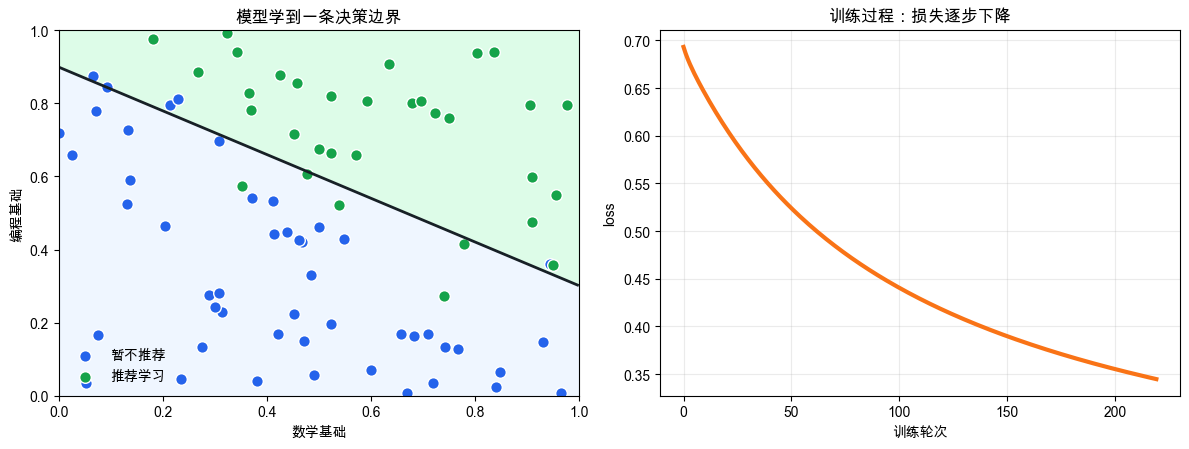

In [7]:
np.random.seed(7)

n = 80
math_score = np.random.rand(n)
code_score = np.random.rand(n)
noise = np.random.normal(0, 0.12, n)
y = (0.55 * math_score + 0.75 * code_score + noise > 0.72).astype(int)

# 用最简单的 logistic regression 训练，避免依赖 sklearn。
w = np.zeros(2)
b = 0.0
lr = 0.6
X = np.c_[math_score, code_score]
losses = []
for _ in range(220):
    z = X @ w + b
    pred = 1 / (1 + np.exp(-z))
    loss = -(y*np.log(pred+1e-9) + (1-y)*np.log(1-pred+1e-9)).mean()
    losses.append(loss)
    dz = pred - y
    w -= lr * (X.T @ dz) / n
    b -= lr * dz.mean()

xx, yy = np.meshgrid(np.linspace(0,1,120), np.linspace(0,1,120))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = (1 / (1 + np.exp(-(grid @ w + b)))).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].contourf(xx, yy, zz, levels=[0, .5, 1], colors=['#eff6ff', '#dcfce7'], alpha=.95)
axes[0].contour(xx, yy, zz, levels=[.5], colors=['#172026'], linewidths=2)
axes[0].scatter(math_score[y==0], code_score[y==0], c='#2563eb', label='暂不推荐', edgecolor='white', s=70)
axes[0].scatter(math_score[y==1], code_score[y==1], c='#16a34a', label='推荐学习', edgecolor='white', s=70)
axes[0].set_xlabel('数学基础')
axes[0].set_ylabel('编程基础')
axes[0].set_title('模型学到一条决策边界')
axes[0].legend(frameon=False)

axes[1].plot(losses, color='#f97316', linewidth=3)
axes[1].set_title('训练过程：损失逐步下降')
axes[1].set_xlabel('训练轮次')
axes[1].set_ylabel('loss')
axes[1].grid(alpha=.25)
plt.tight_layout()
plt.show()

一句话总结：**学习不是“记住答案”，而是找到能推广到新样本的规律。**

这也是后面讲机器学习、神经网络和大模型训练的共同主线。

## 5. 为什么 AI 会发展到今天的大模型

大模型不是突然出现的。它是四件事叠加后的结果：数据更多、算力更强、算法更成熟、工程系统更稳定。

In [8]:
show("""
<div class="ai-course">
  <div class="timeline">
    <div class="titem"><b>规则系统</b><p>专家写规则。可解释，但覆盖不了复杂世界。</p></div>
    <div class="titem"><b>机器学习</b><p>从数据中学习规律。推荐、风控、搜索大量使用。</p></div>
    <div class="titem"><b>深度学习</b><p>神经网络自动学习特征，视觉和语音突破明显。</p></div>
    <div class="titem"><b>Transformer</b><p>注意力机制让模型更擅长处理长序列和上下文。</p></div>
    <div class="titem"><b>大模型</b><p>扩大数据、参数和训练规模，出现强泛化能力。</p></div>
    <div class="titem"><b>Agent</b><p>模型不只回答，还能规划、调用工具、执行任务。</p></div>
  </div>
</div>
""")

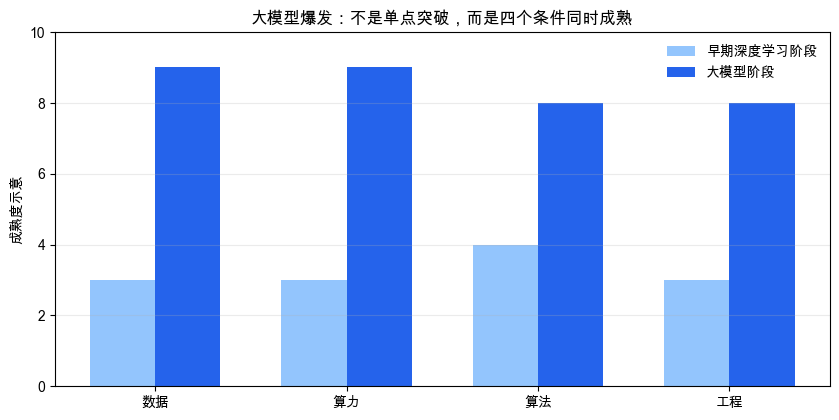

In [9]:
factors = ['数据', '算力', '算法', '工程']
values_2012 = [3, 3, 4, 3]
values_2026 = [9, 9, 8, 8]

x = np.arange(len(factors))
width = 0.34
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.bar(x-width/2, values_2012, width, label='早期深度学习阶段', color='#93c5fd')
ax.bar(x+width/2, values_2026, width, label='大模型阶段', color='#2563eb')
ax.set_xticks(x, factors)
ax.set_ylim(0, 10)
ax.set_ylabel('成熟度示意')
ax.set_title('大模型爆发：不是单点突破，而是四个条件同时成熟')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=.25)
plt.show()

## 6. 大模型、VLM、RAG、Agent 分别是什么位置

这几个词是后面课程最实用的部分，第一节课先建立直觉。

In [10]:
show("""
<div class="ai-course">
  <div class="ladder"><div class="label">LLM</div><div class="bar"><span style="width:70%; background:#2563eb;">以语言为核心：问答、总结、写作、代码</span></div></div>
  <div class="ladder"><div class="label">VLM</div><div class="bar"><span style="width:78%; background:#0891b2;">语言 + 图像：看图问答、图像理解、多模态分析</span></div></div>
  <div class="ladder"><div class="label">RAG</div><div class="bar"><span style="width:86%; background:#16a34a;">模型 + 外部知识库：让回答有依据、可更新</span></div></div>
  <div class="ladder"><div class="label">Agent</div><div class="bar"><span style="width:94%; background:#f97316;">模型 + 工具 + 计划：从回答走向执行</span></div></div>
  <div class="ai-note">课堂讲法：LLM 像会读写的人，VLM 像会看图的人，RAG 像会查资料的人，Agent 像会使用工具完成任务的人。</div>
</div>
""")

### 小实验：一个“生成模型”的最小直觉

Karpathy 的 `makemore` 会从字符预测开始讲语言模型。第一节课不用讲代码细节，只让学生看到：**生成 = 根据上下文预测下一个符号，再不断接下去。**

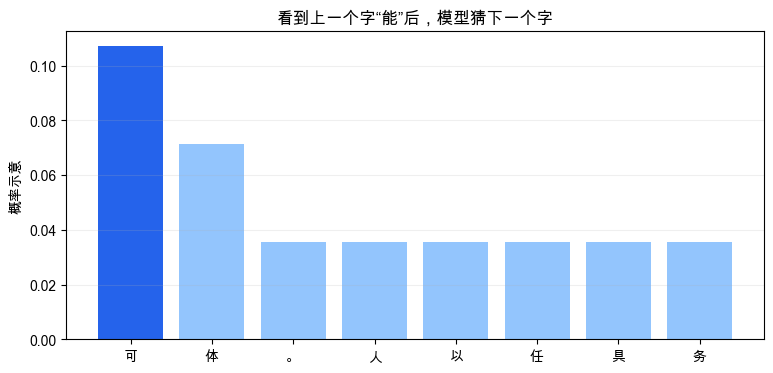

人工智能具文大本本。。能务具调成能完本以理解


In [11]:
text = "人工智能可以理解语言。人工智能可以生成文本。大模型可以调用工具。智能体可以完成任务。"
chars = sorted(set(text))
counts = {c: {d: 1 for d in chars} for c in chars}
for a, b in zip(text, text[1:]):
    counts[a][b] += 1

def next_probs(ch):
    row = counts.get(ch, {d: 1 for d in chars})
    total = sum(row.values())
    return {k: v/total for k, v in row.items()}

context = '能'
probs = next_probs(context)
top = sorted(probs.items(), key=lambda kv: kv[1], reverse=True)[:8]

fig, ax = plt.subplots(figsize=(9, 4))
labels = [k for k, _ in top]
vals = [v for _, v in top]
ax.bar(labels, vals, color=['#2563eb'] + ['#93c5fd']*(len(vals)-1))
ax.set_title(f'看到上一个字“{context}”后，模型猜下一个字')
ax.set_ylabel('概率示意')
ax.grid(axis='y', alpha=.2)
plt.show()

random.seed(3)
out = '人工智能'
for _ in range(18):
    p = next_probs(out[-1])
    letters = list(p.keys())
    weights = list(p.values())
    out += random.choices(letters, weights=weights, k=1)[0]
print(out)

讲课重点：这个小实验很粗糙，但思想非常重要。真正的大模型不是只看上一个字，而是看很长上下文；不是只统计字频，而是用神经网络学习复杂关系。

这正好连接后续路线：

- 第 3 讲：神经网络如何学习。
- 第 7 讲：语言模型如何预测下一个 token。
- 第 8 讲：大模型如何接入知识库和工具。

## 7. AI 应用场景怎么分类

讲应用时不要按行业罗列，容易散。建议按“输入是什么、输出是什么、有没有行动”来讲。

In [12]:
show("""
<div class="ai-course ai-grid">
  <div class="ai-card"><h3>文本输入</h3><p>问答、总结、翻译、写作、代码生成、客服。</p></div>
  <div class="ai-card"><h3>图像输入</h3><p>识别、检测、质检、医学影像、农作物病虫害。</p></div>
  <div class="ai-card"><h3>多模态输入</h3><p>图文问答、文档理解、截图操作、视频分析。</p></div>
  <div class="ai-card"><h3>结构化数据</h3><p>预测、风控、推荐、异常检测、经营分析。</p></div>
  <div class="ai-card"><h3>知识库增强</h3><p>企业文档问答、课程资料问答、法规政策查询。</p></div>
  <div class="ai-card"><h3>工具执行</h3><p>自动填表、查资料、写代码、调用 API、控制设备。</p></div>
</div>
""")

## 8. 本课程 8 次课路线

我们保留学校原来的主题安排，但把内容升级成“底层原理 + 实用大模型 + 可视化演示”。

In [13]:
show("""
<div class="ai-course course-map">
  <div class="lesson"><b>1. 人工智能概述</b><p>建立地图：AI、ML、DL、大模型、VLM、RAG、Agent。</p></div>
  <div class="lesson"><b>2. 机器学习基础</b><p>数据、特征、训练、损失、泛化、过拟合。</p></div>
  <div class="lesson"><b>3. 神经网络基础</b><p>神经元、计算图、梯度、反向传播。参考 micrograd。</p></div>
  <div class="lesson"><b>4. 深度学习模型</b><p>CNN、RNN、注意力、Transformer 的核心思想。</p></div>
  <div class="lesson"><b>5. AI 语言与工具</b><p>Python、Notebook、Prompt、API、向量工具。</p></div>
  <div class="lesson"><b>6. 计算机视觉</b><p>图像分类、CNN、目标检测、VLM 图像理解。</p></div>
  <div class="lesson"><b>7. 自然语言处理</b><p>语言模型、token、embedding、搜索、对话。</p></div>
  <div class="lesson"><b>8. 大模型、VLM、RAG 与 Agent</b><p>把模型接入知识和工具，做可用系统。</p></div>
</div>
""")

## 9. 本节课可直接提问学生的问题

1. AI 和普通程序最本质的区别是什么？
2. 为什么机器学习需要训练数据？
3. 大模型为什么不是 AI 的全部？
4. LLM、VLM、RAG、Agent 分别解决什么问题？
5. 一个 AI 系统要真正落地，除了模型还需要什么？

In [14]:
show("""
<div class="ai-course">
  <div class="ai-warn"><b>课堂收束：</b>AI 的核心不是“会聊天”，而是把输入变成可计算表示，再通过模型输出判断、预测、生成或行动。</div>
  <div class="ai-note"><b>带到下一讲：</b>下一节课开始拆机器学习：数据如何变成模型，模型如何通过损失函数和优化过程学到规律。</div>
</div>
""")

## 参考资料对应关系

本节课主要吸收这些参考资料的结构，但不照搬：

- Microsoft `generative-ai-for-beginners`：生成式 AI、LLM、RAG、Agent 的应用框架。
- D2L《动手学深度学习》：机器学习、深度学习、神经网络的底层路线。
- Karpathy `nn-zero-to-hero`：用 `micrograd` 和 `makemore` 解释反向传播与语言模型的最小原型。